# Perbandingan Prediksi: Moving Average (MA) vs Holt-Winters (HW) (Tahun 2025)
Notebook ini dibuat untuk menampilkan grafik perbandingan antara Data Asli, Prediksi Moving Average (MA), dan Prediksi Holt-Winters (HW) khusus untuk tahun 2025 pada ke-9 bandara.

Parameter terbaik yang digunakan:
- **Holt-Winters**: Dioptimasi menggunakan data mulai tahun 2015 tanpa periode COVID-19.
- **Moving Average**: Dioptimasi menggunakan data mulai tahun 2015 tanpa periode COVID-19.

Memproses SOEKARNO HATTA JAKARTA DOMESTIK...


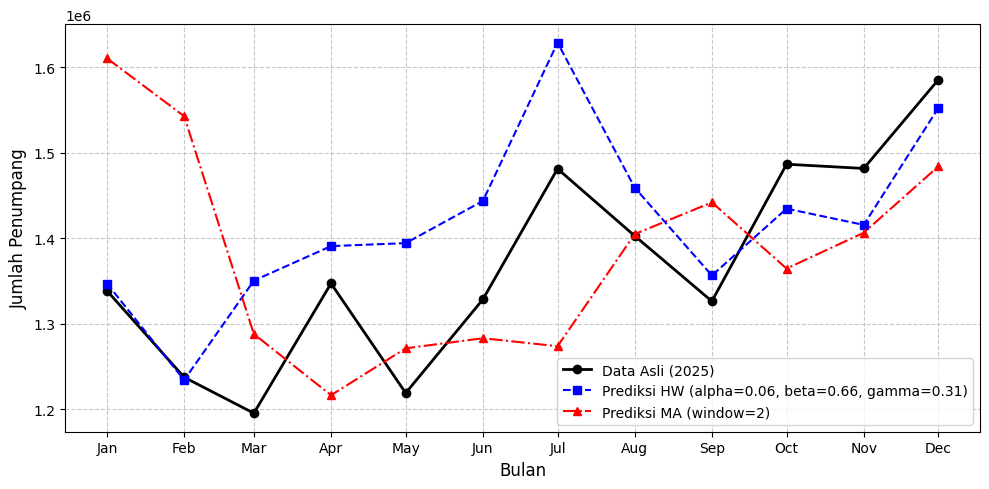

Memproses NGURAH RAI BALI DOMESTIK...


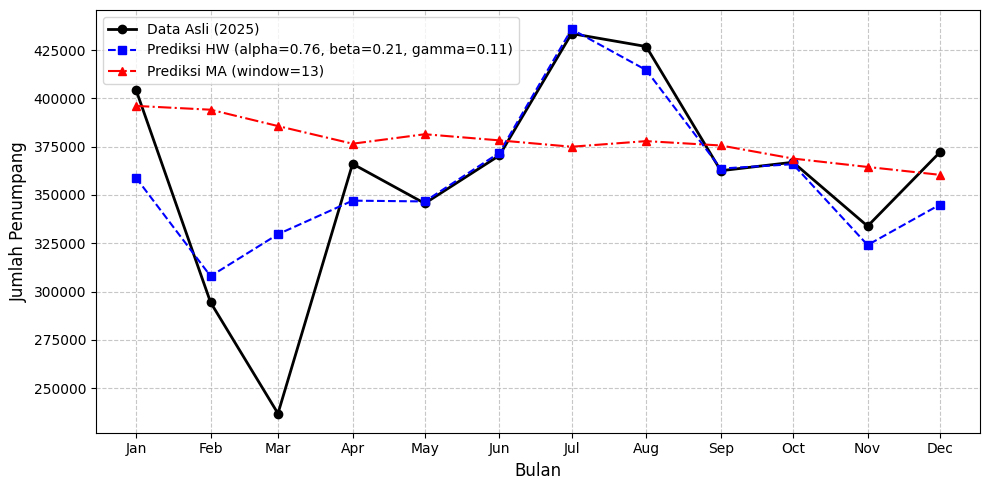

Memproses JUANDA SURABAYA DOMESTIK...


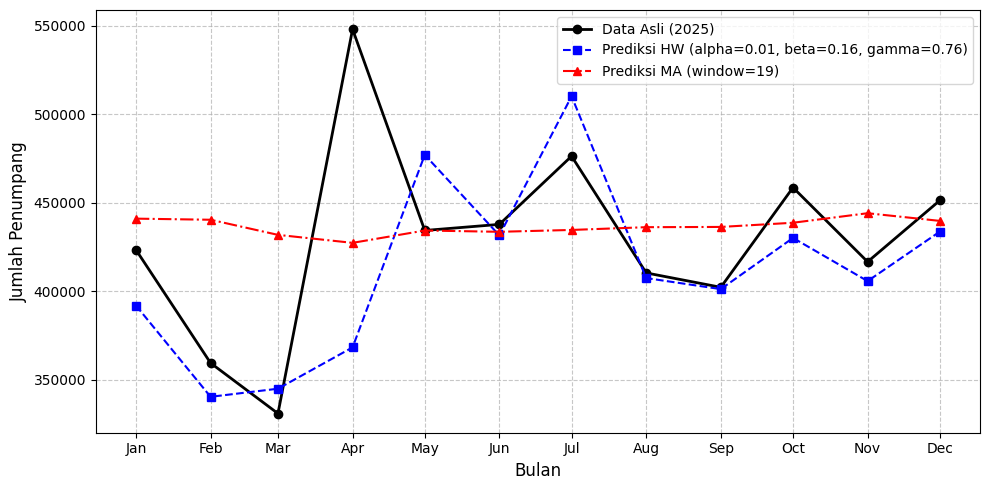

Memproses KUALANAMU MEDAN DOMESTIK...


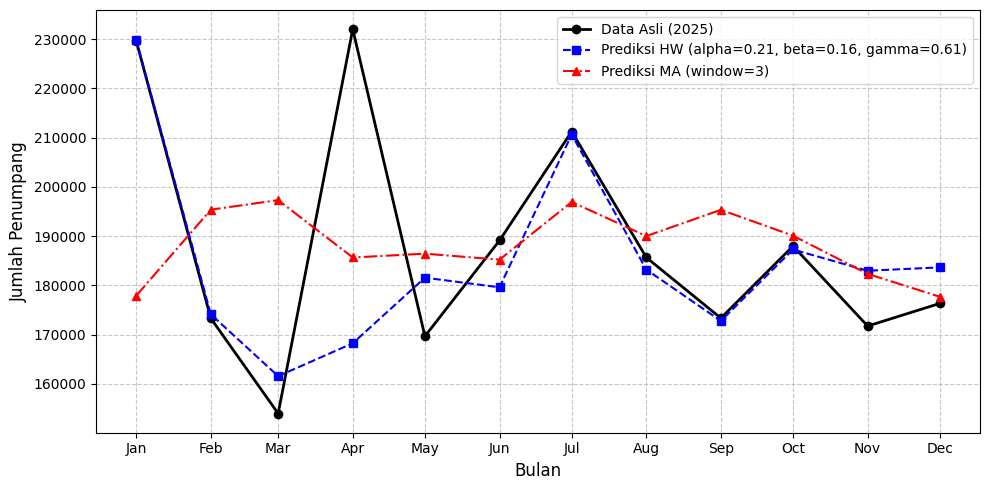

Memproses HASANUDIN MAKASSAR DOMESTIK...


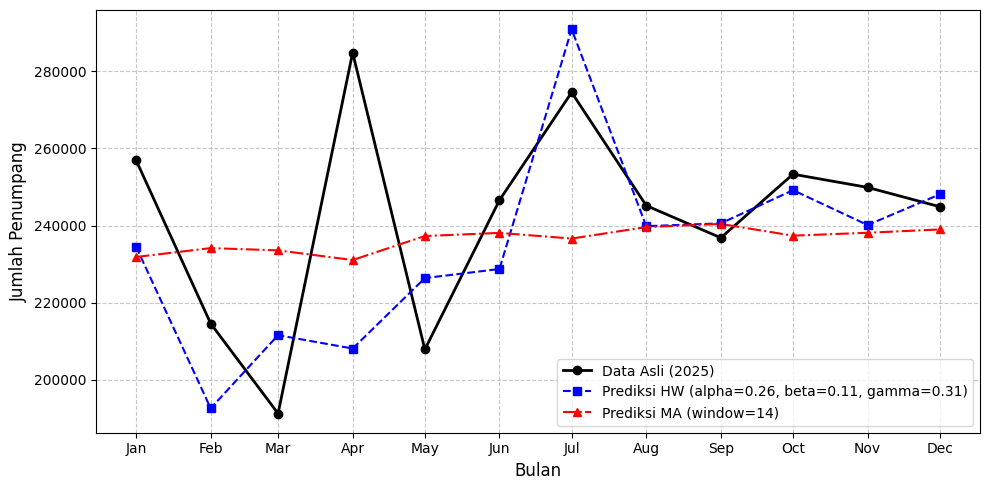

Memproses SOEKARNO HATTA JAKARTA INTERNASIONAL...


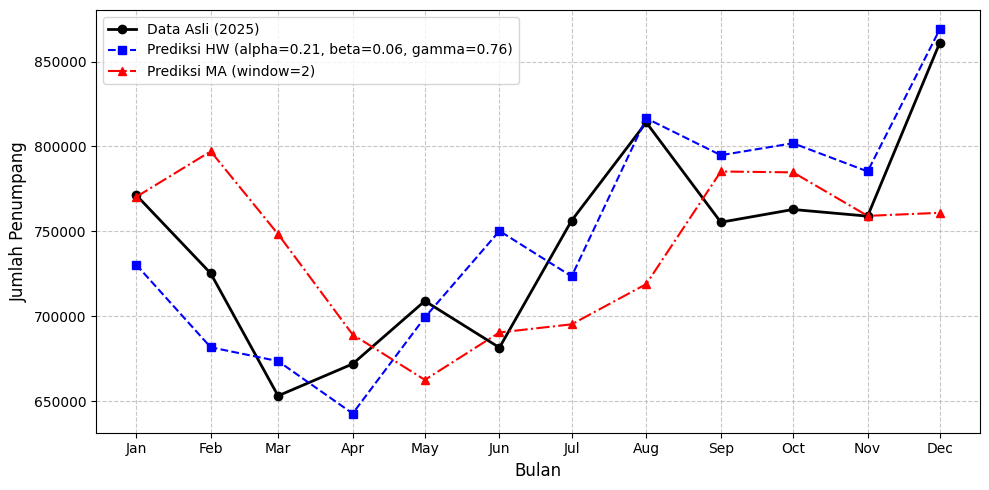

Memproses NGURAH RAI BALI INTERNASIONAL...


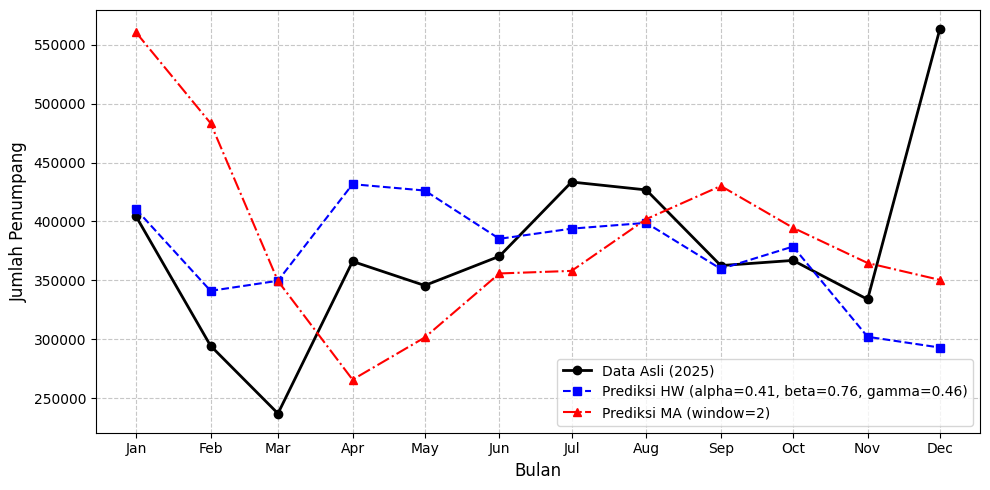

Memproses JUANDA SURABAYA INTERNASIONAL...


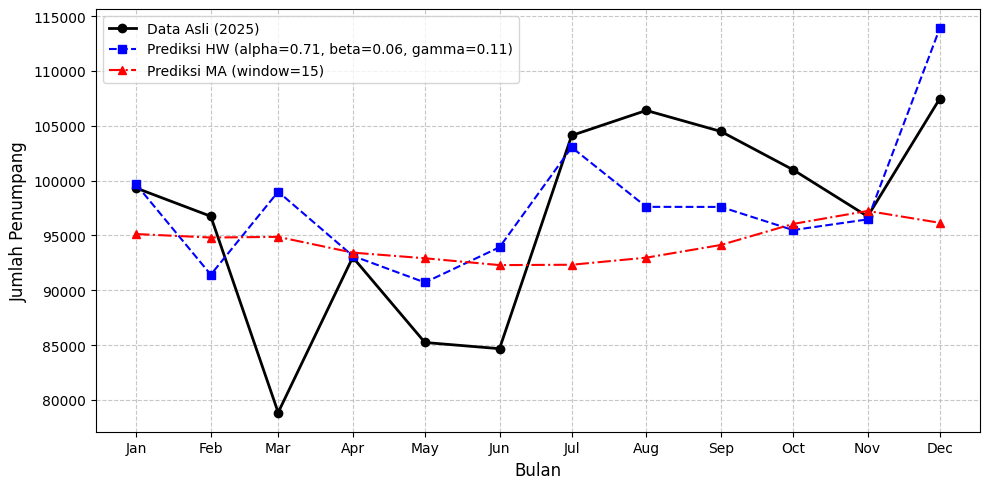

Memproses KUALANAMU MEDAN INTERNASIONAL...


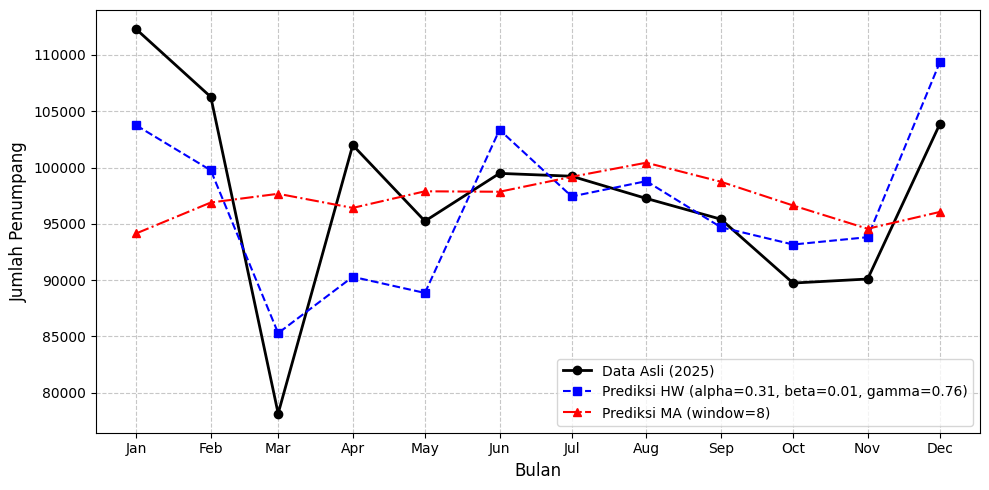

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')


plt.close('all')


file_path = 'target_penumpang_domestik_internasional_2006_2024.xlsx'
df_raw = pd.read_excel(file_path)


bulan_map = {
    'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'Mei':5, 'Jun':6,
    'Jul':7, 'Agu':8, 'Sep':9, 'Okt':10, 'Nov':11, 'Des':12
}
df_raw['Bulan_num'] = df_raw['Bulan'].map(bulan_map)
df_raw['Tanggal'] = pd.to_datetime(df_raw['Tahun'].astype(str) + '-' + df_raw['Bulan_num'].astype(str) + '-01')
df_raw = df_raw.sort_values('Tanggal').reset_index(drop=True)


df_2015 = df_raw[df_raw['Tahun'] >= 2015].reset_index(drop=True)
df_2015 = df_2015[~df_2015['Tahun'].isin([2020, 2021, 2022])].reset_index(drop=True)

bandara_cols = [
    'soekarno_hatta_jakarta_domestik', 'ngurah_rai_bali_domestik', 
    'juanda_surabaya_domestik', 'kualanamu_medan_domestik', 
    'hasanudin_makassar_domestik', 'soekarno_hatta_jakarta_internasional', 
    'ngurah_rai_bali_internasional', 'juanda_surabaya_internasional', 
    'kualanamu_medan_internasional'
]


hw_params = {
    'soekarno_hatta_jakarta_domestik': (0.06, 0.66, 0.31),
    'ngurah_rai_bali_domestik': (0.76, 0.21, 0.11),
    'juanda_surabaya_domestik': (0.01, 0.16, 0.76),
    'kualanamu_medan_domestik': (0.21, 0.16, 0.61),
    'hasanudin_makassar_domestik': (0.26, 0.11, 0.31),
    'soekarno_hatta_jakarta_internasional': (0.21, 0.06, 0.76),
    'ngurah_rai_bali_internasional': (0.41, 0.76, 0.46),
    'juanda_surabaya_internasional': (0.71, 0.06, 0.11),
    'kualanamu_medan_internasional': (0.31, 0.01, 0.76)
}


ma_params = {
    'soekarno_hatta_jakarta_domestik': 2,
    'ngurah_rai_bali_domestik': 13,
    'juanda_surabaya_domestik': 19,
    'kualanamu_medan_domestik': 3,
    'hasanudin_makassar_domestik': 14,
    'soekarno_hatta_jakarta_internasional': 2,
    'ngurah_rai_bali_internasional': 2,
    'juanda_surabaya_internasional': 15,
    'kualanamu_medan_internasional': 8
}


for i, col in enumerate(bandara_cols):
    print(f"Memproses {col.replace('_', ' ').upper()}...")
    
    data = df_2015[col].values
    split_idx = int(len(data) * 0.8)
    train, test = data[:split_idx], data[split_idx:]
    test_dates = df_2015['Tanggal'].values[split_idx:]
    

    a, b, g = hw_params[col]
    model_hw = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
    fit_hw = model_hw.fit(smoothing_level=a, smoothing_trend=b, smoothing_seasonal=g, optimized=False)
    preds_hw = fit_hw.forecast(len(test))
    
   
    w = ma_params[col]
    temp_train_ma = list(train).copy()
    preds_ma = []
    

    for test_val in test:
        m = np.mean(temp_train_ma[-w:])
        preds_ma.append(m)
        temp_train_ma.append(test_val)  
        
    preds_ma = np.array(preds_ma)
    

    mask_2025 = pd.DatetimeIndex(test_dates).year == 2025
    test_dates_2025 = test_dates[mask_2025]
    test_2025 = test[mask_2025]
    preds_hw_2025 = preds_hw[mask_2025]
    preds_ma_2025 = preds_ma[mask_2025]
    
  
    fig = plt.figure(figsize=(10, 5))
    

    plt.plot(test_dates_2025, test_2025, label='Data Asli (2025)', color='black', marker='o', markersize=6, linewidth=2)

    plt.plot(test_dates_2025, preds_hw_2025, label=f'Prediksi HW (alpha={a}, beta={b}, gamma={g})', color='blue', linestyle='--', marker='s', markersize=6)
    plt.plot(test_dates_2025, preds_ma_2025, label=f'Prediksi MA (window={w})', color='red', linestyle='-.', marker='^', markersize=6)
    

    plt.xticks(test_dates_2025, pd.DatetimeIndex(test_dates_2025).strftime('%b'))
    
    plt.xlabel('Bulan', fontsize=12)
    plt.ylabel('Jumlah Penumpang', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
  
    plt.show()
    
    plt.close(fig)
